# Action Vector Pathways

**Biological question**: Do perturbations targeting genes in the same pathway produce similar action vectors?

**Metrics**: Silhouette score, k-NN accuracy

## Setup

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from collections import Counter

from eval_common import get_paths, load_biojepa_model, load_perturbation_bank, update_eval_report
from pathway_utils import load_pathway_annotations, map_genes_to_pathways, compute_pathway_clustering_metrics, get_pathway_summary

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using {device}')

paths = get_paths()
biojepa = load_biojepa_model(paths, device)

Using cpu
<All keys matched successfully>


## Load Pathway Annotations

In [3]:
pathway_libs = load_pathway_annotations(['KEGG_2021_Human', 'Reactome_Pathways_2024'])

Loading KEGG_2021_Human...
  320 pathways loaded
Loading Reactome_Pathways_2024...
  2100 pathways loaded


In [4]:
with open(paths['data_dir'] / 'gene_names.json') as f:
    gene_names = json.load(f)
print(f'Loaded {len(gene_names)} gene names')

Loaded 5000 gene names


---
## Action Vector Analysis

Extract action vectors for all perturbations and measure whether perturbations targeting genes in the same pathway cluster together.

In [11]:
input_bank = load_perturbation_bank(paths, device)

with open(paths['pert_dir'] / 'input_to_id.json') as f:
    input_to_id = json.load(f)

id_to_gene = {}
for pert_key, pert_id in input_to_id.items():
    gene_name = pert_key.split('_')[0].upper()
    id_to_gene[pert_id] = gene_name

print(f'Loaded {len(id_to_gene)} perturbation -> gene mappings')

Input Bank (DNA): torch.Size([1250, 1536])
Loaded 1250 perturbation -> gene mappings


In [12]:
n_perts = input_bank.shape[0]
p_mod = torch.zeros(n_perts, dtype=torch.long, device=device)
p_mode = torch.zeros(n_perts, dtype=torch.long, device=device)

with torch.no_grad():
    action_vectors = biojepa.composer(input_bank, p_mod, p_mode).cpu().numpy()

print(f'Action vectors shape: {action_vectors.shape}')

Action vectors shape: (1250, 320)


In [13]:
gene_to_pathway_kegg = {}
for pathway, genes in pathway_libs['KEGG_2021_Human'].items():
    if 15 <= len(genes) <= 300:
        for gene in genes:
            if gene.upper() not in gene_to_pathway_kegg:
                gene_to_pathway_kegg[gene.upper()] = pathway

pert_pathway_labels = {}
for pert_id, gene in id_to_gene.items():
    if gene in gene_to_pathway_kegg:
        pert_pathway_labels[pert_id] = gene_to_pathway_kegg[gene]

print(f'Perturbations with KEGG pathway labels: {len(pert_pathway_labels)}')

Perturbations with KEGG pathway labels: 636


### Action Vector Clustering Metrics

In [14]:
action_indices = list(pert_pathway_labels.keys())
action_embeddings = action_vectors[action_indices]
action_labels = [pert_pathway_labels[i] for i in action_indices]

action_kegg_metrics = compute_pathway_clustering_metrics(action_embeddings, action_labels, min_samples_per_class=5)
print('KEGG Action Vector Metrics:')
print(f'  Silhouette Score: {action_kegg_metrics["silhouette_score"]:.4f}')
print(f'  k-NN Accuracy: {action_kegg_metrics["knn_accuracy"]:.4f}')
print(f'  Classes: {action_kegg_metrics["n_classes"]}, Samples: {action_kegg_metrics["n_samples"]}')

KEGG Action Vector Metrics:
  Silhouette Score: -0.4122
  k-NN Accuracy: 0.3495
  Classes: 27, Samples: 515


### Action Vector Visualization

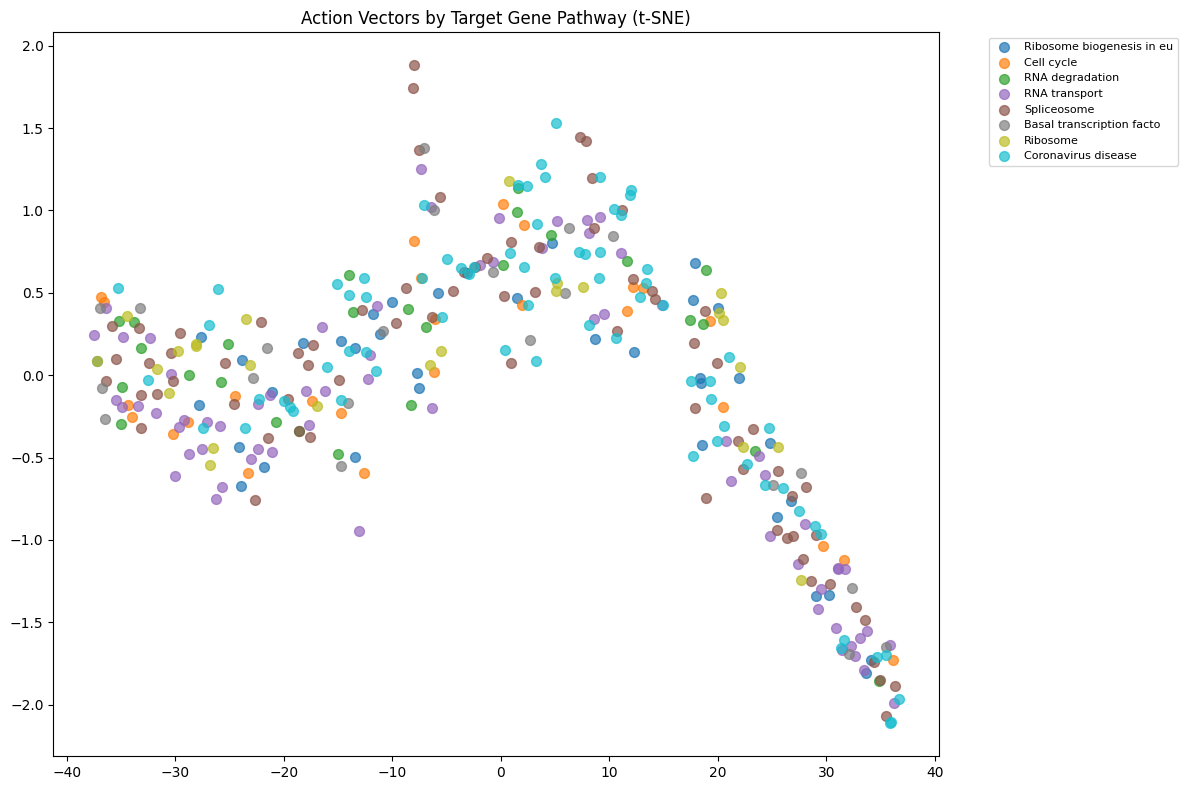

In [15]:
pathway_counts = Counter(action_labels)
top_action_pathways = [p for p, c in pathway_counts.most_common(8) if c >= 5]

viz_action_indices, viz_action_labels = [], []
for pert_id, pathway in pert_pathway_labels.items():
    if pathway in top_action_pathways:
        viz_action_indices.append(pert_id)
        viz_action_labels.append(pathway[:25])

if len(viz_action_indices) > 30:
    viz_action_embeddings = action_vectors[viz_action_indices]
    tsne = TSNE(n_components=2, perplexity=min(30, len(viz_action_indices) // 2), random_state=42)
    viz_action_2d = tsne.fit_transform(viz_action_embeddings)

    plt.figure(figsize=(12, 8))
    unique_labels = list(set(viz_action_labels))
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    for i, label in enumerate(unique_labels):
        mask = np.array(viz_action_labels) == label
        plt.scatter(viz_action_2d[mask, 0], viz_action_2d[mask, 1], c=[colors[i]], label=label, alpha=0.7, s=50)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.title('Action Vectors by Target Gene Pathway (t-SNE)')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough perturbations for visualization')

In [16]:
print('='*70)
print('ACTION VECTOR PATHWAYS - RESULTS')
print('='*70)
print()
print('KEGG Pathways:')
print(f'  Silhouette Score: {action_kegg_metrics["silhouette_score"]:.4f}')
print(f'  k-NN Accuracy:    {action_kegg_metrics["knn_accuracy"]:.4f}')
print(f'  Pathways: {action_kegg_metrics["n_classes"]}, Perturbations: {action_kegg_metrics["n_samples"]}')


In [17]:
update_eval_report('action_vector_pathways', {
    'config': {'n_perturbations': len(id_to_gene)},
    'kegg': action_kegg_metrics
})